## Notebook 03 - Topological metrics per team
Núria Pascual Salas

**Content:** Computes global topological metrics (density, global efficiency,
clustering, average path length, reciprocity) at two levels: the season-aggregated
network per team, and the 760 individual team-match networks. Relates these metrics
to points, and tests whether playing style (r(SF, Points)) is linked to the per-team
density--points correlation.

**Inputs:** sf_per_team_correlations.csv (from notebook 01).

**Outputs:**
- outputs/csv/topological_metrics_per_team.csv
- outputs/csv/topological_metrics_per_match.csv
- outputs/csv/topo_per_team_correlations.csv
- outputs/figures/topological_metrics_heatmap.png
- outputs/figures/match_metrics_distributions.png
- outputs/figures/style_vs_structure.png

**Used in:** Chapter 3 (Topological characterisation).

In [1]:
from utils import *
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import defaultdict
from scipy.stats import pearsonr


FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'

### 1. Season-aggregated network and global metrics per team

In [2]:
consolidated_networks = {}

for team_id, team_name in all_teams.items():
    print(f"Building consolidated network for {team_name}...")
    G_team, n = build_consolidated_network(team_id, team_name, zip_path, folder_laliga)
    consolidated_networks[team_name] = {
        'graph':     G_team,
        'n_matches': n,
        'team_id':   team_id,
    }
    print(f"  {n} matches | {G_team.number_of_nodes()} players | {G_team.number_of_edges()} edges")

Building consolidated network for Atlético Madrid...
  38 matches | 27 players | 502 edges
Building consolidated network for Granada...
  38 matches | 40 players | 769 edges
Building consolidated network for Celta Vigo...
  38 matches | 31 players | 672 edges
Building consolidated network for Osasuna...
  38 matches | 29 players | 511 edges
Building consolidated network for Sevilla...
  38 matches | 35 players | 784 edges
Building consolidated network for Valencia...
  38 matches | 30 players | 542 edges
Building consolidated network for Las Palmas...
  38 matches | 29 players | 596 edges
Building consolidated network for Mallorca...
  38 matches | 25 players | 500 edges
Building consolidated network for Cádiz...
  38 matches | 33 players | 664 edges
Building consolidated network for Deportivo Alavés...
  38 matches | 29 players | 498 edges
Building consolidated network for Real Sociedad...
  38 matches | 31 players | 640 edges
Building consolidated network for Girona...
  38 matches |

In [5]:
team_metrics_rows = []

for team_name, data in consolidated_networks.items():
    metrics = compute_topological_metrics(data['graph'])
    metrics['team']   = team_name
    metrics['team_id'] = data['team_id']
    team_metrics_rows.append(metrics)

df_team_metrics = pd.DataFrame(team_metrics_rows)
df_team_metrics = df_team_metrics[[
    'team', 'n_nodes', 'n_edges', 'density',
    'efficiency', 'clustering', 'avg_path_length', 'reciprocity'
]].round(4)
df_team_metrics = df_team_metrics.sort_values('efficiency', ascending=False)

print(df_team_metrics.to_string(index=False))
df_team_metrics.to_csv(f'{CSV_DIR}/topological_metrics_per_team.csv', index=False)

            team  n_nodes  n_edges  density  efficiency  clustering  avg_path_length  reciprocity
        Mallorca       25      500   0.8333      0.9350      0.1240           1.1667       0.9560
   Athletic Club       27      561   0.7991      0.9274      0.0627           1.2023       0.9305
  Rayo Vallecano       26      491   0.7554      0.8969      0.0758           1.2062       0.9491
      Celta Vigo       31      672   0.7226      0.8935      0.0501           1.2785       0.9107
      Las Palmas       29      596   0.7340      0.8929      0.0338           1.2660       0.9295
     Real Madrid       27      513   0.7308      0.8903      0.1044           1.2194       0.9318
      Villarreal       32      727   0.7329      0.8901      0.0727           1.2671       0.9354
       Barcelona       29      591   0.7278      0.8867      0.0806           1.2722       0.9374
 Atlético Madrid       27      502   0.7151      0.8775      0.0712           1.2450       0.9442
      Real Betis    

### 2. Heatmap of team metrics

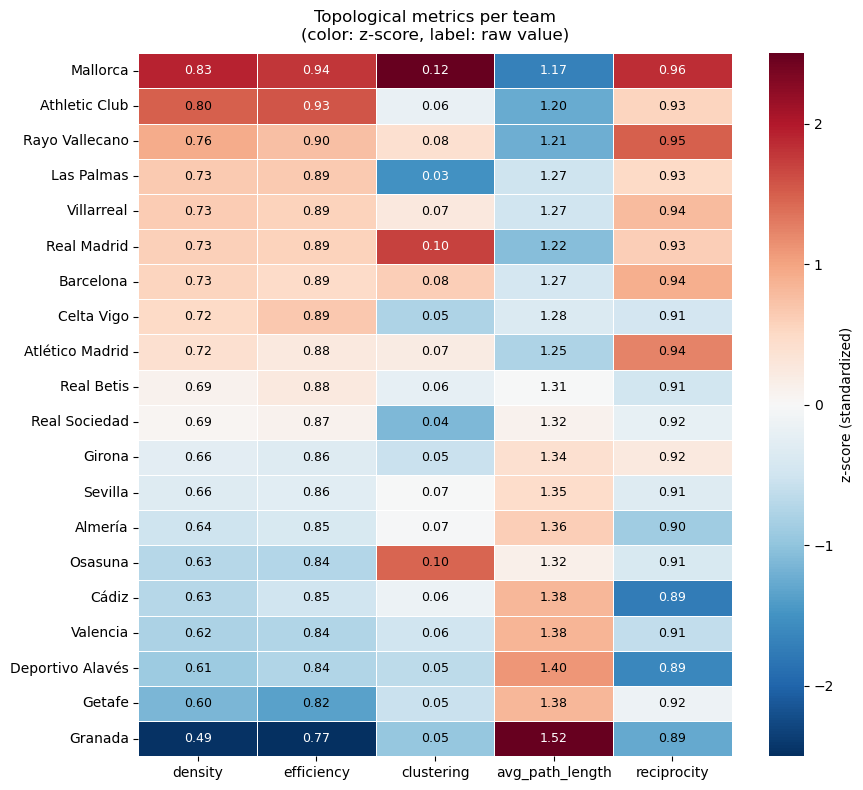

In [ ]:
metrics = ['density', 'efficiency', 'clustering', 'avg_path_length', 'reciprocity']

# Standardize each metric (z-score) so they share the same color scale
df_z = df_team_metrics.copy()
for m in metrics:
    df_z[m] = (df_team_metrics[m] - df_team_metrics[m].mean()) / df_team_metrics[m].std()

# Sort teams by density (descending) for visual ordering
df_z = df_z.sort_values('density', ascending=False).reset_index(drop=True)

# Set team as index for the heatmap
df_heatmap = df_z.set_index('team')[metrics]
df_annot   = df_team_metrics.set_index('team').loc[df_heatmap.index, metrics]

# Plot
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(df_heatmap, annot=df_annot,
            fmt='.2f',
            cmap='RdBu_r',
            center=0, vmin=-2.5, vmax=2.5,
            cbar_kws={'label': 'z-score (standardized)'},
            linewidths=0.4, linecolor='white',
            annot_kws={'fontsize': 9},
            ax=ax)

for text, z_val in zip(ax.texts, df_heatmap.values.flatten()):
    text.set_color('white' if abs(z_val) > 1.5 else 'black')

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Topological metrics per team\n(color: z-score, label: raw value)',
             fontsize=12, pad=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/topological_metrics_heatmap.png',
            dpi=130, bbox_inches='tight')
plt.show()

### 3. Match-by-match metrics (760 team-match networks)

In [7]:
all_match_metrics = []

print("Computing topological metrics for all team-match pairs...")

for team_id, team_name in all_teams.items():
    for m_id, events in stream_matches_from_zip(zip_path, folder_laliga, "_events.json"):
        teams_in_match = {e['team']['id'] for e in events if 'team' in e}
        if team_id not in teams_in_match:
            continue
        
        G = build_passing_network(events, team_name)
        metrics = compute_topological_metrics(G)
        
        sf            = calculate_match_sf(events, team_id)
        avg_ec, _     = calcular_ec_equip(events, team_name)
        _, _, res, pts = get_match_result(events, team_id)
        
        metrics.update({
            'team':     team_name,
            'team_id':  team_id,
            'match_id': m_id,
            'sf':       sf,
            'ec':       avg_ec,
            'result':   res,
            'points':   pts,
        })
        all_match_metrics.append(metrics)
    
    print(f"  {team_name} done")

df_match_metrics = pd.DataFrame(all_match_metrics)
df_match_metrics.to_csv(f'{CSV_DIR}/topological_metrics_per_match.csv', index=False)
print(f"\nTotal team-match observations: {len(df_match_metrics)}")
df_match_metrics.head()

Computing topological metrics for all team-match pairs...
  Deportivo Alavés done
  Granada done
  Barcelona done
  Almería done
  Sevilla done
  Cádiz done
  Girona done
  Athletic Club done
  Real Sociedad done
  Mallorca done
  Real Betis done
  Atlético Madrid done
  Villarreal done
  Celta Vigo done
  Valencia done
  Las Palmas done
  Osasuna done
  Real Madrid done
  Getafe done
  Rayo Vallecano done

Total team-match observations: 760


,n_nodes,n_edges,density,efficiency,clustering,avg_path_length,reciprocity,team,team_id,match_id,sf,ec,result,points
0,15,102,0.485714,0.809524,0.099004,1.552381,0.725490,Deportivo Alavés,206,3894664,0.247409,0.219907,win,3
1,16,100,0.416667,0.783333,0.089693,1.679167,0.640000,Deportivo Alavés,206,3894825,0.255587,0.199964,lost,0
2,15,93,0.442857,0.800000,0.174352,1.666667,0.645161,Deportivo Alavés,206,3894839,0.294224,0.213373,win,3
3,16,104,0.433333,0.781944,0.174094,1.475000,0.653846,Deportivo Alavés,206,3894905,0.272277,0.221111,draw,1
4,16,105,0.437500,0.794444,0.242003,1.625000,0.647619,Deportivo Alavés,206,3894751,0.237160,0.218172,lost,0


### 4. Distribution of topological metrics per match

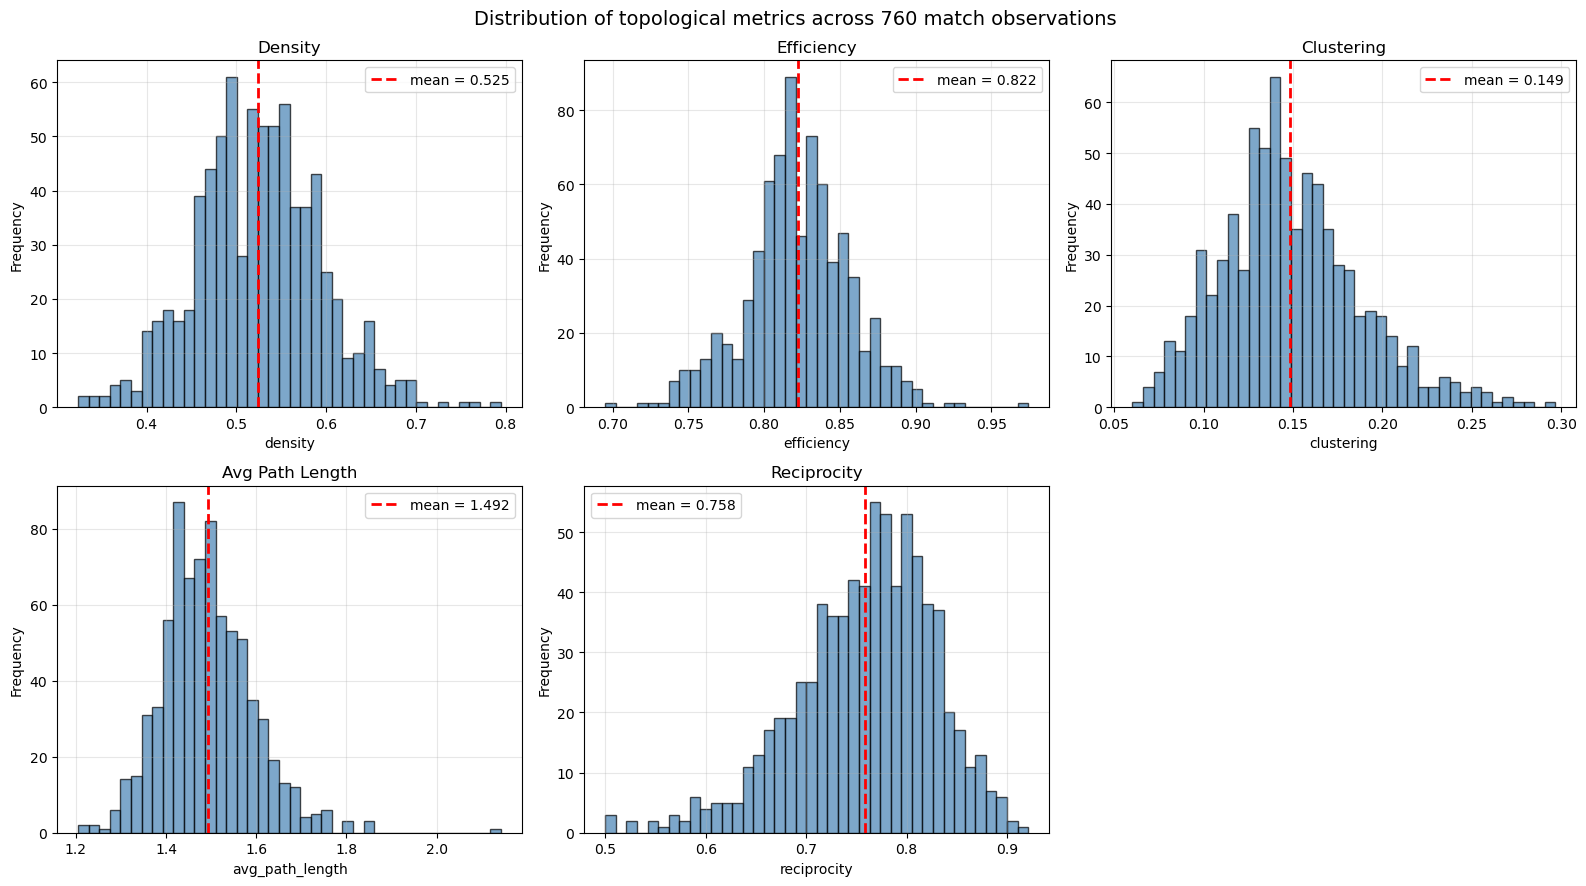

In [8]:
metrics_to_plot = ['density', 'efficiency', 'clustering', 'avg_path_length', 'reciprocity']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    data = df_match_metrics[metric].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2,
               label=f'mean = {data.mean():.3f}')
    ax.set_title(metric.replace('_', ' ').title(), fontsize=12)
    ax.set_xlabel(metric)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Distribution of topological metrics across 760 match observations', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/match_metrics_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

### 5. Correlation between topological metrics and points

In [9]:
# Per-team correlations
per_team_corr = []

for team_name in all_teams.values():
    df_team = df_match_metrics[df_match_metrics['team'] == team_name].dropna(
        subset=['density', 'efficiency', 'clustering', 'points']
    )
    if len(df_team) < 10:
        continue
    
    row = {'team': team_name}
    for metric in ['density', 'efficiency', 'clustering', 'avg_path_length', 'reciprocity']:
        if df_team[metric].nunique() > 1:
            r, p = stats.pearsonr(df_team[metric], df_team['points'])
            row[f'r_{metric}']  = round(r, 3)
            row[f'p_{metric}']  = round(p, 4)
    per_team_corr.append(row)

df_per_team_corr = pd.DataFrame(per_team_corr)
df_per_team_corr.to_csv(f'{CSV_DIR}/topo_per_team_correlations.csv', index=False)

print(df_per_team_corr.to_string(index=False))

            team  r_density  p_density  r_efficiency  p_efficiency  r_clustering  p_clustering  r_avg_path_length  p_avg_path_length  r_reciprocity  p_reciprocity
Deportivo Alavés     -0.077     0.6455        -0.042        0.8005         0.166        0.3204             -0.087             0.6019         -0.110         0.5096
         Granada     -0.321     0.0495        -0.299        0.0687        -0.182        0.2728              0.223             0.1792         -0.137         0.4124
       Barcelona     -0.302     0.0656        -0.367        0.0236        -0.236        0.1543              0.256             0.1202          0.072         0.6689
         Almería     -0.006     0.9732        -0.147        0.3769        -0.002        0.9900             -0.096             0.5656          0.246         0.1364
         Sevilla     -0.613     0.0000        -0.610        0.0000         0.021        0.8989              0.501             0.0014         -0.479         0.0023
           Cádiz     -

In [10]:
# Global pooled correlations (all 760 observations)
print("\nGlobal pooled correlations (across all 760 observations):")
for metric in ['density', 'efficiency', 'clustering', 'avg_path_length', 'reciprocity']:
    df_clean = df_match_metrics.dropna(subset=[metric, 'points'])
    if len(df_clean) > 10:
        r, p = stats.pearsonr(df_clean[metric], df_clean['points'])
        print(f"  r({metric:18s}, points) = {r:+.3f}  (p = {p:.4f}, n = {len(df_clean)})")


Global pooled correlations (across all 760 observations):
  r(density           , points) = -0.008  (p = 0.8283, n = 760)
  r(efficiency        , points) = -0.065  (p = 0.0744, n = 760)
  r(clustering        , points) = -0.066  (p = 0.0706, n = 760)
  r(avg_path_length   , points) = -0.019  (p = 0.6021, n = 760)
  r(reciprocity       , points) = +0.089  (p = 0.0137, n = 760)


### 6. Playing style vs density–points correlation


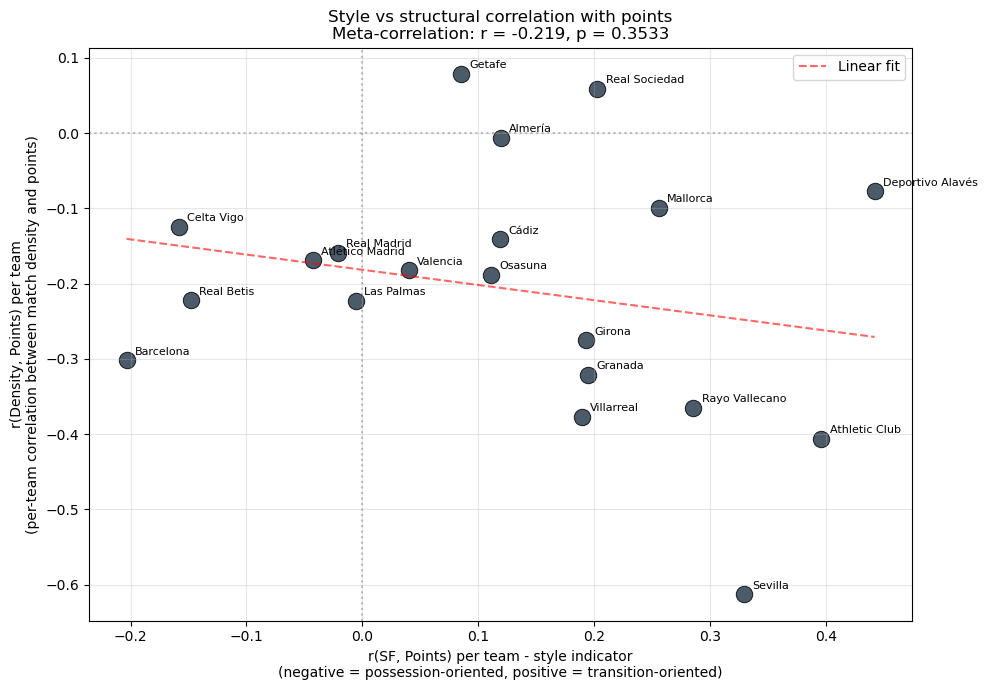


Meta-correlation: r = -0.219, p = 0.3533
Interpretation:
  Pattern weaker than expected - interpretation needs nuance.


In [11]:
# Load the per-team r(SF, Points) computed in notebook 01
df_style = pd.read_csv(f'{CSV_DIR}/sf_per_team_correlations.csv')

# Merge with the per-team density-points correlations from this notebook
df_plot = df_per_team_corr[['team', 'r_density']].merge(
    df_style[['team', 'r_sf_points']], on='team'
)

# Compute the correlation between the two correlation vectors
r_meta, p_meta = pearsonr(df_plot['r_sf_points'], df_plot['r_density'])

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df_plot['r_sf_points'], df_plot['r_density'],
           s=140, alpha=0.85, color='#2c3e50',
           edgecolors='black', linewidths=0.7)

for _, row in df_plot.iterrows():
    ax.annotate(row['team'],
                (row['r_sf_points'], row['r_density']),
                fontsize=8, textcoords='offset points', xytext=(6, 4))

# Linear fit
m, b = np.polyfit(df_plot['r_sf_points'], df_plot['r_density'], 1)
x_line = np.linspace(df_plot['r_sf_points'].min(),
                     df_plot['r_sf_points'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linestyle='--', alpha=0.6,
        linewidth=1.5, label=f'Linear fit')

# Quadrant lines
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)

ax.set_xlabel('r(SF, Points) per team - style indicator\n'
              '(negative = possession-oriented, positive = transition-oriented)',
              fontsize=10)
ax.set_ylabel('r(Density, Points) per team\n'
              '(per-team correlation between match density and points)',
              fontsize=10)
ax.set_title(f'Style vs structural correlation with points\n'
             f'Meta-correlation: r = {r_meta:+.3f}, p = {p_meta:.4f}',
             fontsize=12)
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/style_vs_density_correlation.png',
            dpi=130, bbox_inches='tight')
plt.show()

print(f"\nMeta-correlation: r = {r_meta:+.3f}, p = {p_meta:.4f}")
print("Interpretation:")
if r_meta < -0.3 and p_meta < 0.05:
    print("  Confirms the pattern: transition teams (positive r_sf_points)")
    print("  show negative density-points correlation.")
elif abs(r_meta) < 0.3:
    print("  Pattern weaker than expected - interpretation needs nuance.")
else:
    print("  Unexpected direction or pattern.")